In [24]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [49]:
TICKER = 'SPY'
WINDOW = 20
FAST = 10
SLOW = 27
LOOKBACK = 10000

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,10_ma,27_ma,Strategy,Asset Returns,Strategy Returns
Date,,,,,,,,,,
2020-02-11,307.219971,308.832751,306.688464,308.044692,54864500,302.234045,300.830569,1.0,0.001733,0.001733
2020-02-12,309.199310,309.410056,308.292092,308.658631,43992700,303.223712,301.339995,1.0,0.008187,0.008187
2020-02-13,308.869446,309.840789,307.494901,307.769799,54501900,304.083267,301.795460,1.0,0.007111,0.007111
2020-02-14,309.364288,309.483420,308.081385,309.281819,64582200,305.537527,302.300138,1.0,0.008725,0.008725
2020-02-18,308.567108,309.428492,307.174218,308.365507,57226200,306.693073,302.716916,1.0,0.006126,0.006126
...,...,...,...,...,...,...,...,...,...,...
2026-03-12,666.059998,671.650024,665.869995,671.159973,108882200,678.936005,684.059631,-1.0,1.171780,0.275527
2026-03-13,662.289978,672.340027,661.359985,669.270020,97200200,676.566003,683.050741,-1.0,1.159488,0.282747
2026-03-16,669.030029,672.070007,667.119995,668.380005,82023100,674.831006,682.415186,-1.0,1.181465,0.269693


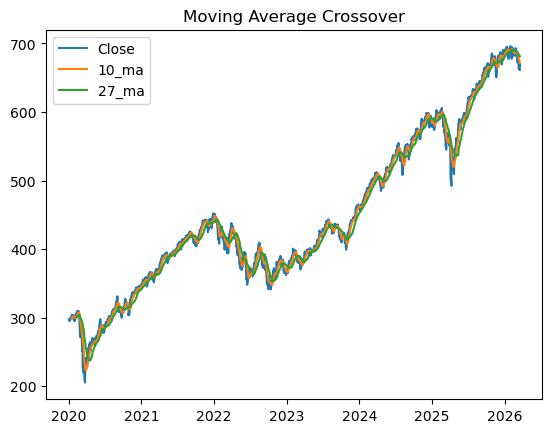

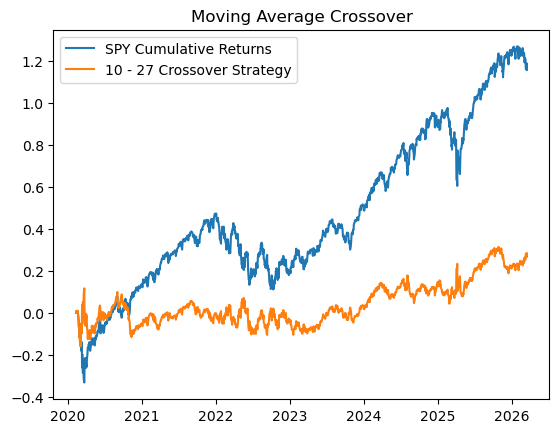

In [50]:
def get_data():
    df = yf.download(TICKER, start='2020-01-01')
    df.columns = df.columns.get_level_values(0)

    return df.iloc[-LOOKBACK:, :]
    
def add_moving_averages(df,fast,slow):
    df[f'{FAST}_ma'] = df['Close'].rolling(fast).mean()
    df[f'{SLOW}_ma'] = df['Close'].rolling(slow).mean()


    plt.plot(df['Close'])
    plt.plot(df[f'{FAST}_ma'])
    plt.plot(df[f'{SLOW}_ma'])
    plt.legend(['Close',f'{FAST}_ma',f'{SLOW}_ma'])
    plt.title('Moving Average Crossover')
    return df.dropna()

def add_strategy(df,fast,slow):
    #long when fast > slow, short otherwise
    df['Strategy'] = np.where(df[f'{fast}_ma'] > df[f'{slow}_ma'],1,-1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df

def test_strategy(df,ticker,fast,slow):
    df['Asset Returns'] = (1 +df['Close'].pct_change()).cumprod() - 1
    df['Strategy Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1

    plt.figure()
    plt.plot(df['Asset Returns'])
    plt.plot(df['Strategy Returns'])
    plt.legend([f'{ticker} Cumulative Returns', f'{fast} - {slow} Crossover Strategy'])
    plt.title('Moving Average Crossover')

    return df.dropna()

df = get_data()
df = add_moving_averages(df,FAST,SLOW)
df = add_strategy(df,FAST,SLOW)
df = test_strategy(df, TICKER,FAST, SLOW)

df
